<a href="https://colab.research.google.com/github/vcanio/MineriaDeDatos/blob/main/Premier_League_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de la Premier League — Minería de Datos aplicada al fútbol

**Dataset:** `epl_final.csv` — Resultados históricos de la Premier League (2000–2025)  
**Metodología:** CRISP-DM  
**Enfoque del proyecto:** evaluación de modelos, segmentación K-Means, salidas para Power BI y bonus de integración mediante `.pkl` + API Flask.

> El proyecto aplica minería de datos al análisis histórico de partidos de Premier League, con foco en predicción, segmentación de equipos y visualización de resultados para apoyar la toma de decisiones.


---
## Fase 1 — Comprensión del negocio

### Contexto
La Premier League tiene un comportamiento competitivo donde el marcador al medio tiempo, la localía, los goles y el estilo de cada equipo pueden entregar señales útiles para el análisis deportivo.

### Propuesta de valor
El proyecto busca apoyar la toma de decisiones mediante tres resultados principales:

1. **Predicción del resultado final** desde información disponible al medio tiempo.
2. **Estimación de goles totales** esperados en el partido.
3. **Segmentación de equipos con K-Means** para identificar perfiles deportivos de rendimiento.

### Decisión metodológica importante
Para que la predicción sea defendible, los modelos de clasificación y regresión usan variables disponibles al medio tiempo. De esta forma se evita usar información que solo se conoce al final del partido.

### Alcance del proyecto
El bonus elegido es la integración del modelo mediante archivo `.pkl` y una API simple con Flask.


---
## Fase 2 — Comprensión de los datos

Se carga el dataset histórico de partidos y se revisa su estructura general. La exploración se mantiene enfocada en variables útiles para el modelado, la evaluación y la toma de decisiones.


### 2.1 Importación de librerías

In [1]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

OUTPUT_DIR = Path('salidas_proyecto')
POWERBI_DIR = OUTPUT_DIR / 'powerbi'
MODELOS_DIR = OUTPUT_DIR / 'modelos'
POWERBI_DIR.mkdir(parents=True, exist_ok=True)
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

### 2.2 Carga del dataset

In [2]:
csv_path = 'epl_final.csv'
if not os.path.exists(csv_path):
    csv_path = '/content/epl_final.csv'

df = pd.read_csv(csv_path)
print(f'Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas')
display(df.head())

Dimensiones del dataset: 9380 filas y 22 columnas


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,17,8,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,17,12,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,6,16,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,6,13,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,17,12,8,6,6,4,21,20,1,3,0,0


### 2.3 Diccionario breve de variables principales

| Variable | Descripción |
|---|---|
| `Season` | Temporada del partido |
| `HomeTeam` / `AwayTeam` | Equipo local y visitante |
| `FullTimeHomeGoals` / `FullTimeAwayGoals` | Goles al final del partido |
| `FullTimeResult` | Resultado final: H local, D empate, A visitante |
| `HalfTimeHomeGoals` / `HalfTimeAwayGoals` | Goles al medio tiempo |
| `HalfTimeResult` | Resultado al descanso |
| `HomeShots`, `AwayShots`, tarjetas, córners | Estadísticas completas del partido usadas para análisis descriptivo y K-Means |

### 2.4 Calidad de datos

In [3]:
print('Tipos de datos:')
display(df.dtypes)

print('\nValores nulos por columna:')
display(df.isnull().sum().to_frame('nulos'))

Tipos de datos:


,0
Season,object
MatchDate,object
HomeTeam,object
AwayTeam,object
FullTimeHomeGoals,int64
FullTimeAwayGoals,int64
FullTimeResult,object
HalfTimeHomeGoals,int64
HalfTimeAwayGoals,int64
HalfTimeResult,object



Valores nulos por columna:


,nulos
Season,0
MatchDate,0
HomeTeam,0
AwayTeam,0
FullTimeHomeGoals,0
FullTimeAwayGoals,0
FullTimeResult,0
HalfTimeHomeGoals,0
HalfTimeAwayGoals,0
HalfTimeResult,0


### 2.5 Resumen descriptivo

In [4]:
display(df.describe())

print('Distribución de resultados finales:')
display(df['FullTimeResult'].value_counts().rename(index={'H':'Victoria local', 'D':'Empate', 'A':'Victoria visitante'}))

print('Distribución de resultados al medio tiempo:')
display(df['HalfTimeResult'].value_counts().rename(index={'H':'Ventaja local', 'D':'Empate', 'A':'Ventaja visitante'}))

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


Distribución de resultados finales:


,count
FullTimeResult,
Victoria local,4299
Victoria visitante,2768
Empate,2313


Distribución de resultados al medio tiempo:


,count
HalfTimeResult,
Empate,3840
Ventaja local,3290
Ventaja visitante,2250


### 2.6 Visualizaciones exploratorias principales

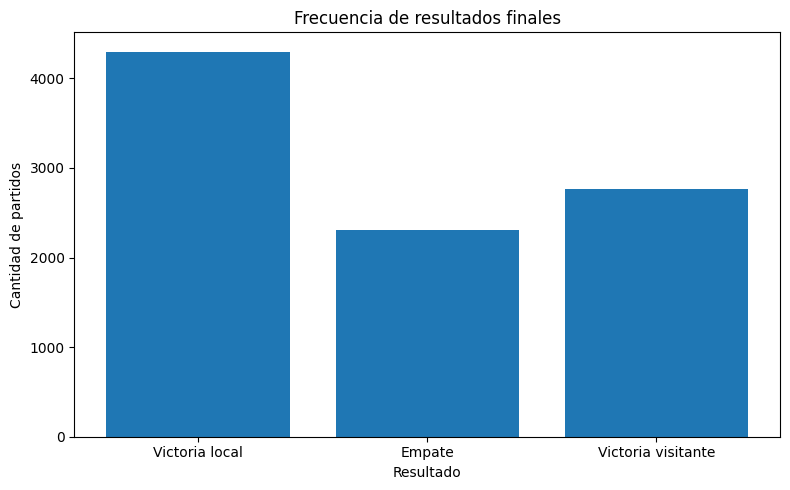

In [5]:
# Frecuencia de resultados finales
resultado_final = df['FullTimeResult'].value_counts().reindex(['H', 'D', 'A'])
resultado_final.index = ['Victoria local', 'Empate', 'Victoria visitante']

plt.figure(figsize=(8, 5))
plt.bar(resultado_final.index, resultado_final.values)
plt.title('Frecuencia de resultados finales')
plt.xlabel('Resultado')
plt.ylabel('Cantidad de partidos')
plt.tight_layout()
plt.show()

**Lectura para la toma de decisiones:** esta visualización permite verificar la ventaja histórica de localía y sirve como línea base para interpretar cualquier modelo predictivo.

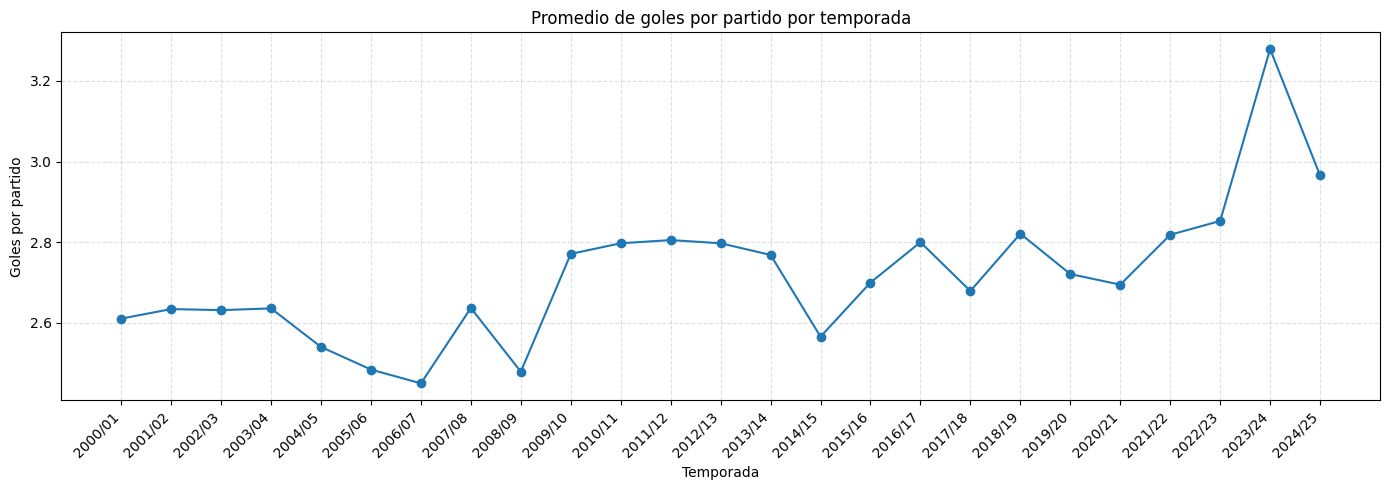

In [6]:
# Evolución de goles por temporada
goles_temporada = (
    df.assign(GolesTotales=df['FullTimeHomeGoals'] + df['FullTimeAwayGoals'])
      .groupby('Season', as_index=False)
      .agg(Partidos=('Season', 'count'), GolesTotales=('GolesTotales', 'sum'))
)
goles_temporada['GolesPorPartido'] = goles_temporada['GolesTotales'] / goles_temporada['Partidos']

plt.figure(figsize=(14, 5))
plt.plot(goles_temporada['Season'], goles_temporada['GolesPorPartido'], marker='o')
plt.title('Promedio de goles por partido por temporada')
plt.xlabel('Temporada')
plt.ylabel('Goles por partido')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Lectura para la toma de decisiones:** el promedio de goles por partido ayuda a identificar temporadas más ofensivas o cerradas, lo que puede apoyar análisis deportivos y visualizaciones ejecutivas.

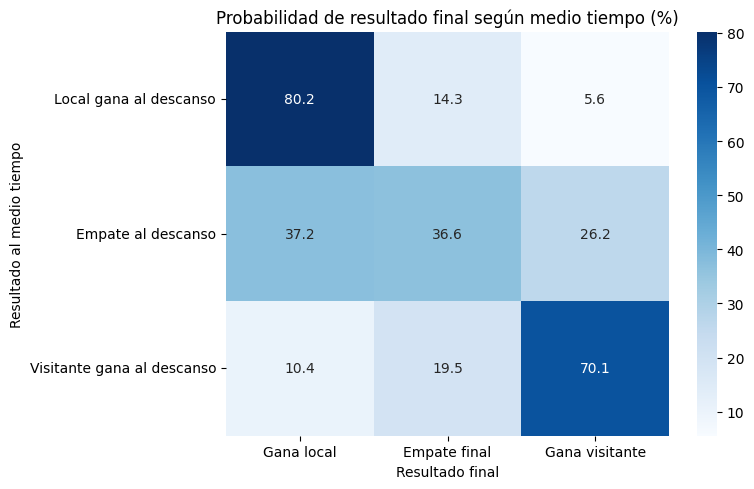

In [7]:
# Relación entre resultado al medio tiempo y resultado final
tabla_transicion = pd.crosstab(
    df['HalfTimeResult'],
    df['FullTimeResult'],
    normalize='index'
).reindex(index=['H', 'D', 'A'], columns=['H', 'D', 'A']) * 100

tabla_transicion.index = ['Local gana al descanso', 'Empate al descanso', 'Visitante gana al descanso']
tabla_transicion.columns = ['Gana local', 'Empate final', 'Gana visitante']

plt.figure(figsize=(8, 5))
sns.heatmap(tabla_transicion, annot=True, fmt='.1f', cmap='Blues')
plt.title('Probabilidad de resultado final según medio tiempo (%)')
plt.xlabel('Resultado final')
plt.ylabel('Resultado al medio tiempo')
plt.tight_layout()
plt.show()

**Lectura para la toma de decisiones:** esta matriz muestra si la ventaja al descanso suele mantenerse. Por eso el medio tiempo es la base lógica del modelo de clasificación.

---
## Fase 3 — Preparación de datos

Se crean variables derivadas simples y se codifican los resultados. La preparación se enfoca en evitar fuga de datos en los modelos predictivos.

### 3.1 Codificación e ingeniería de características

In [8]:
# Codificación de resultado final y resultado al medio tiempo
label_encoder_resultado = LabelEncoder()
df['FullTimeResult_Encoded'] = label_encoder_resultado.fit_transform(df['FullTimeResult'])

label_encoder_medio_tiempo = LabelEncoder()
df['HalfTimeResult_Encoded'] = label_encoder_medio_tiempo.fit_transform(df['HalfTimeResult'])

print('Mapeo resultado final:')
for clase, codigo in zip(label_encoder_resultado.classes_, label_encoder_resultado.transform(label_encoder_resultado.classes_)):
    print(f'{clase} -> {codigo}')

# Variables derivadas
df['HalfTimeGoalDiff'] = df['HalfTimeHomeGoals'] - df['HalfTimeAwayGoals']
df['TotalHalfTimeGoals'] = df['HalfTimeHomeGoals'] + df['HalfTimeAwayGoals']
df['FullTimeGoalDiff'] = df['FullTimeHomeGoals'] - df['FullTimeAwayGoals']
df['TotalFullTimeGoals'] = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals']
df['SecondHalfHomeGoals'] = df['FullTimeHomeGoals'] - df['HalfTimeHomeGoals']
df['SecondHalfAwayGoals'] = df['FullTimeAwayGoals'] - df['HalfTimeAwayGoals']

display(df[['HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HalfTimeGoalDiff', 'TotalHalfTimeGoals', 'FullTimeResult']].head())

Mapeo resultado final:
A -> 0
D -> 1
H -> 2


,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeGoalDiff,TotalHalfTimeGoals,FullTimeResult
0,2,0,2,2,H
1,1,0,1,1,H
2,1,1,0,2,A
3,1,2,-1,3,D
4,2,0,2,2,H


### 3.2 Selección de variables para modelos predictivos

Para clasificación y regresión se usan solo variables disponibles al descanso:

- `HalfTimeHomeGoals`
- `HalfTimeAwayGoals`
- `HalfTimeResult_Encoded`
- `HalfTimeGoalDiff`
- `TotalHalfTimeGoals`

Esto hace que la predicción sea coherente con un escenario real de análisis durante el partido.

In [9]:
columnas_predictoras = [
    'HalfTimeHomeGoals',
    'HalfTimeAwayGoals',
    'HalfTimeResult_Encoded',
    'HalfTimeGoalDiff',
    'TotalHalfTimeGoals'
]

X = df[columnas_predictoras]
y_clasificacion = df['FullTimeResult_Encoded']
y_regresion = df['TotalFullTimeGoals']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clasificacion,
    test_size=0.20,
    random_state=42,
    stratify=y_clasificacion
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regresion,
    test_size=0.20,
    random_state=42
)

print(f'Clasificación - entrenamiento: {X_train.shape[0]} partidos | prueba: {X_test.shape[0]} partidos')
print(f'Regresión - entrenamiento: {X_train_reg.shape[0]} partidos | prueba: {X_test_reg.shape[0]} partidos')

Clasificación - entrenamiento: 7504 partidos | prueba: 1876 partidos
Regresión - entrenamiento: 7504 partidos | prueba: 1876 partidos


---
## Fase 4 — Modelado

En esta fase se entrenan tres enfoques:

1. **Clasificación:** predecir resultado final del partido.
2. **Regresión:** estimar goles totales del partido.
3. **K-Means:** agrupar equipos según perfil deportivo histórico.

### 4.1 Modelo de clasificación — Árbol de decisión

In [10]:
modelo_clasificacion = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=40,
    random_state=42
)
modelo_clasificacion.fit(X_train, y_train)

print('Modelo de clasificación entrenado correctamente.')

Modelo de clasificación entrenado correctamente.


**Justificación:** se usa un árbol de decisión porque es fácil de explicar. Permite mostrar reglas basadas en goles y resultado al medio tiempo, que son variables simples para una presentación.

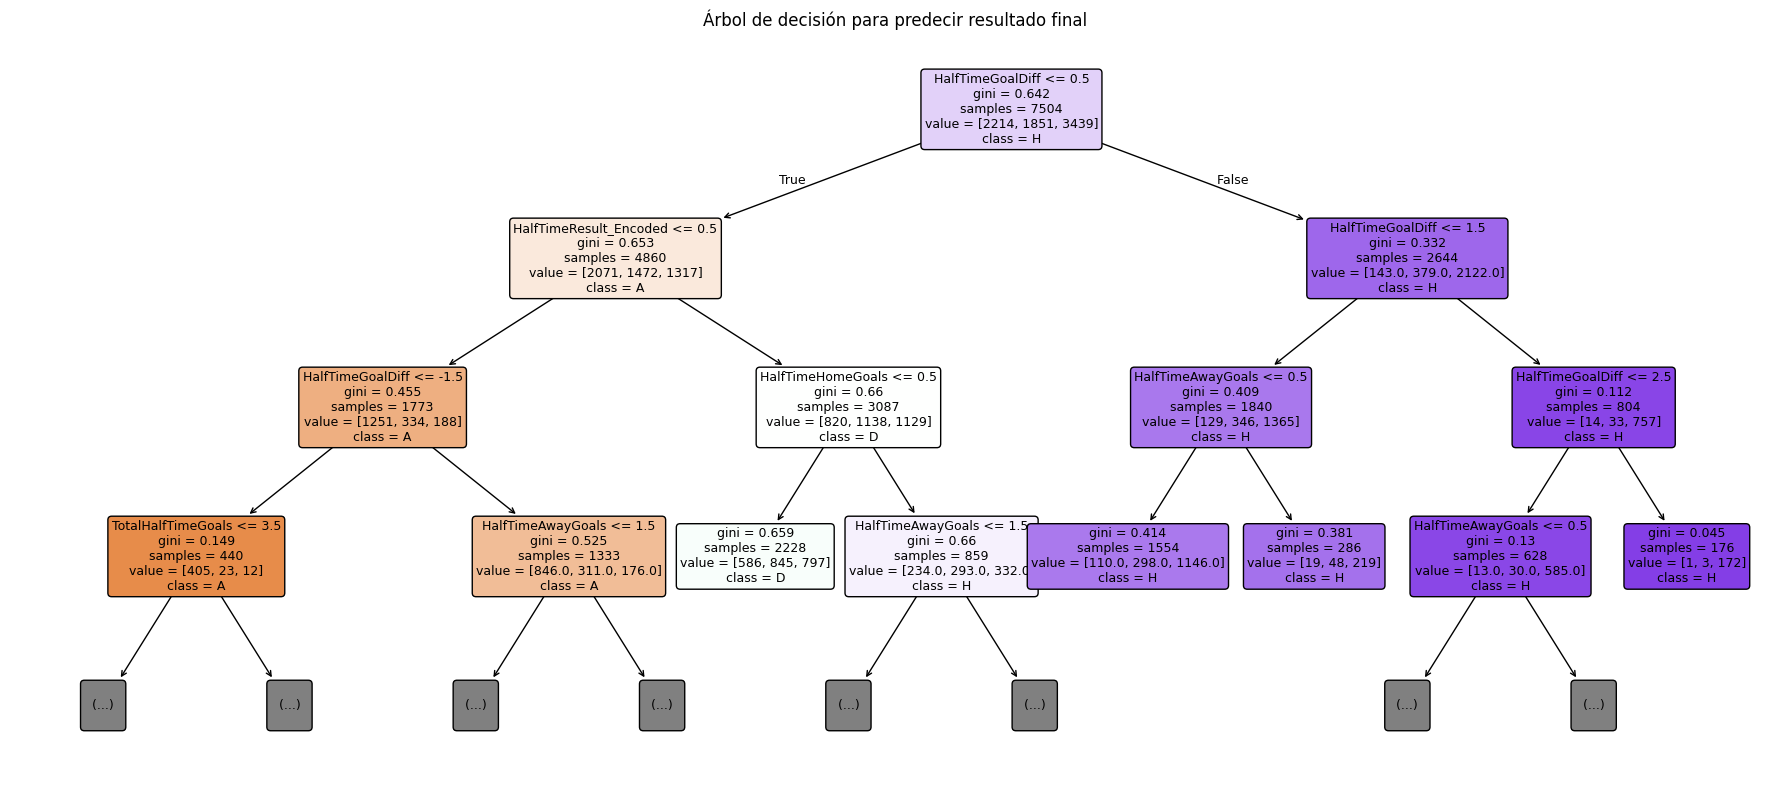

In [11]:
plt.figure(figsize=(18, 8))
plot_tree(
    modelo_clasificacion,
    feature_names=columnas_predictoras,
    class_names=list(label_encoder_resultado.classes_),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title('Árbol de decisión para predecir resultado final')
plt.tight_layout()
plt.show()

### 4.2 Modelo de regresión — Random Forest Regressor

In [12]:
modelo_regresion = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=1
)
modelo_regresion.fit(X_train_reg, y_train_reg)

print('Modelo de regresión entrenado correctamente.')

Modelo de regresión entrenado correctamente.


**Justificación:** se usa regresión para estimar el total de goles del partido desde el estado del marcador al descanso. Esto complementa la clasificación, porque no solo indica quién podría ganar, sino también qué tan abierto puede ser el partido.

### 4.3 K-Means — Segmentación de equipos

In [13]:
# Construcción de dataset agregado por equipo
teams = sorted(set(df['HomeTeam']) | set(df['AwayTeam']))
team_rows = []

for team in teams:
    home = df[df['HomeTeam'] == team]
    away = df[df['AwayTeam'] == team]
    matches = len(home) + len(away)

    points = (
        home['FullTimeResult'].eq('H').sum() * 3 + home['FullTimeResult'].eq('D').sum() +
        away['FullTimeResult'].eq('A').sum() * 3 + away['FullTimeResult'].eq('D').sum()
    )

    team_rows.append({
        'Team': team,
        'Matches': matches,
        'GoalsForAvg': (home['FullTimeHomeGoals'].sum() + away['FullTimeAwayGoals'].sum()) / matches,
        'GoalsAgainstAvg': (home['FullTimeAwayGoals'].sum() + away['FullTimeHomeGoals'].sum()) / matches,
        'ShotsAvg': (home['HomeShots'].sum() + away['AwayShots'].sum()) / matches,
        'ShotsOnTargetAvg': (home['HomeShotsOnTarget'].sum() + away['AwayShotsOnTarget'].sum()) / matches,
        'CornersAvg': (home['HomeCorners'].sum() + away['AwayCorners'].sum()) / matches,
        'YellowCardsAvg': (home['HomeYellowCards'].sum() + away['AwayYellowCards'].sum()) / matches,
        'RedCardsAvg': (home['HomeRedCards'].sum() + away['AwayRedCards'].sum()) / matches,
        'PointsPerMatch': points / matches
    })

team_df = pd.DataFrame(team_rows)
display(team_df.head())

,Team,Matches,GoalsForAvg,GoalsAgainstAvg,ShotsAvg,ShotsOnTargetAvg,CornersAvg,YellowCardsAvg,RedCardsAvg,PointsPerMatch
0,Arsenal,937,1.897545,1.038420,14.181430,6.629669,6.318036,1.553895,0.086446,1.940235
1,Aston Villa,825,1.258182,1.391515,11.256970,4.987879,5.556364,1.738182,0.064242,1.294545
2,Birmingham,258,1.023256,1.352713,9.093023,4.705426,4.949612,1.624031,0.096899,1.131783
3,Blackburn,408,1.245098,1.411765,11.125000,5.730392,5.384804,1.811275,0.120098,1.274510
4,Blackpool,38,1.447368,2.052632,11.736842,6.184211,4.894737,1.236842,0.052632,1.026316


,k,Inertia,Silhouette,CalinskiHarabasz,DaviesBouldin
0,2,208.857521,0.509865,33.526536,0.566566
1,3,161.125552,0.332446,27.604564,1.164682
2,4,137.299335,0.237572,23.523852,1.338866
3,5,118.620903,0.262720,21.548780,1.215347
4,6,103.930675,0.241276,20.326574,1.215334


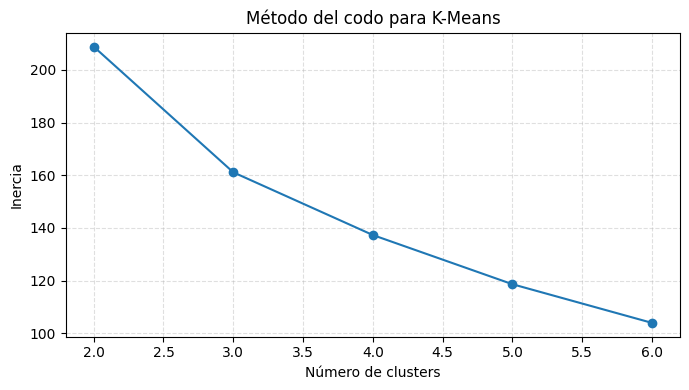

In [14]:
cluster_features = [
    'GoalsForAvg', 'GoalsAgainstAvg', 'ShotsAvg', 'ShotsOnTargetAvg',
    'CornersAvg', 'YellowCardsAvg', 'RedCardsAvg', 'PointsPerMatch'
]

scaler_kmeans = StandardScaler()
team_scaled = scaler_kmeans.fit_transform(team_df[cluster_features])

kmeans_eval = []
for k in range(2, 7):
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_temp = modelo_temp.fit_predict(team_scaled)
    kmeans_eval.append({
        'k': k,
        'Inertia': modelo_temp.inertia_,
        'Silhouette': silhouette_score(team_scaled, labels_temp),
        'CalinskiHarabasz': calinski_harabasz_score(team_scaled, labels_temp),
        'DaviesBouldin': davies_bouldin_score(team_scaled, labels_temp)
    })

kmeans_eval_df = pd.DataFrame(kmeans_eval)
display(kmeans_eval_df)

plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval_df['k'], kmeans_eval_df['Inertia'], marker='o')
plt.title('Método del codo para K-Means')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
# Se eligen 3 clusters para mantener una segmentación simple y defendible.
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
team_df['Cluster'] = modelo_kmeans.fit_predict(team_scaled)

# Etiquetas interpretables según rendimiento promedio del cluster
cluster_summary = team_df.groupby('Cluster')[['GoalsForAvg', 'GoalsAgainstAvg', 'PointsPerMatch']].mean()
orden_rendimiento = cluster_summary['PointsPerMatch'].sort_values(ascending=False).index.tolist()
cluster_labels = {
    orden_rendimiento[0]: 'Alto rendimiento',
    orden_rendimiento[1]: 'Rendimiento medio',
    orden_rendimiento[2]: 'Rendimiento bajo'
}
team_df['ClusterLabel'] = team_df['Cluster'].map(cluster_labels)

display(team_df.sort_values(['ClusterLabel', 'PointsPerMatch'], ascending=[True, False]).head(15))

,Team,Matches,GoalsForAvg,GoalsAgainstAvg,ShotsAvg,ShotsOnTargetAvg,CornersAvg,YellowCardsAvg,RedCardsAvg,PointsPerMatch,Cluster,ClusterLabel
27,Man United,938,1.816631,0.987207,14.452026,6.751599,6.164179,1.627932,0.057569,1.975480,2,Alto rendimiento
0,Arsenal,937,1.897545,1.038420,14.181430,6.629669,6.318036,1.553895,0.086446,1.940235,2,Alto rendimiento
13,Chelsea,937,1.815368,0.962647,14.949840,6.654216,6.156884,1.683031,0.072572,1.935966,2,Alto rendimiento
24,Liverpool,938,1.862473,0.979744,15.591684,6.872068,6.553305,1.343284,0.056503,1.932836,2,Alto rendimiento
26,Man City,900,1.910000,1.050000,14.843333,6.531111,6.576667,1.514444,0.074444,1.855556,2,Alto rendimiento
40,Tottenham,938,1.621535,1.260128,13.607676,6.247335,5.860341,1.583156,0.069296,1.626866,2,Alto rendimiento
31,Nott'm Forest,111,1.270270,1.594595,11.234234,3.792793,3.765766,2.126126,0.045045,1.216216,0,Rendimiento bajo
10,Burnley,342,0.997076,1.558480,10.453216,3.643275,4.426901,1.695906,0.046784,1.020468,0,Rendimiento bajo
30,Norwich,262,0.938931,1.828244,10.824427,4.332061,4.618321,1.500000,0.061069,0.870229,0,Rendimiento bajo
35,Sheffield United,152,0.828947,1.717105,9.532895,3.585526,4.638158,1.940789,0.078947,0.861842,0,Rendimiento bajo


**Justificación:** K-Means se usa para **segmentar equipos por similitud de rendimiento y estilo de juego**. No es una clasificación supervisada, porque el algoritmo no recibe una etiqueta real como “bueno” o “malo”. Primero agrupa equipos parecidos según sus estadísticas; después se interpreta cada grupo como perfil de alto, medio o bajo rendimiento según sus promedios deportivos.

---
## Fase 5 — Evaluación

Esta fase valida el rendimiento de los modelos y traduce los resultados a conclusiones útiles para la toma de decisiones.

### 5.1 Evaluación del modelo de clasificación

In [16]:
y_pred = modelo_clasificacion.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
baseline = y_test.value_counts(normalize=True).max()
cv_scores = cross_val_score(modelo_clasificacion, X, y_clasificacion, cv=5, scoring='accuracy')

print(f'Accuracy: {accuracy:.3f}')
print(f'Balanced Accuracy: {balanced_acc:.3f}')
print(f'Baseline clase mayoritaria: {baseline:.3f}')
print(f'Cross Validation Accuracy promedio: {cv_scores.mean():.3f}')
print(f'Cross Validation desviación estándar: {cv_scores.std():.3f}')

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=label_encoder_resultado.classes_))

Accuracy: 0.595
Balanced Accuracy: 0.571
Baseline clase mayoritaria: 0.458
Cross Validation Accuracy promedio: 0.603
Cross Validation desviación estándar: 0.008

Reporte de clasificación:
              precision    recall  f1-score   support

           A       0.69      0.59      0.63       554
           D       0.36      0.44      0.40       462
           H       0.70      0.68      0.69       860

    accuracy                           0.59      1876
   macro avg       0.58      0.57      0.57      1876
weighted avg       0.61      0.59      0.60      1876



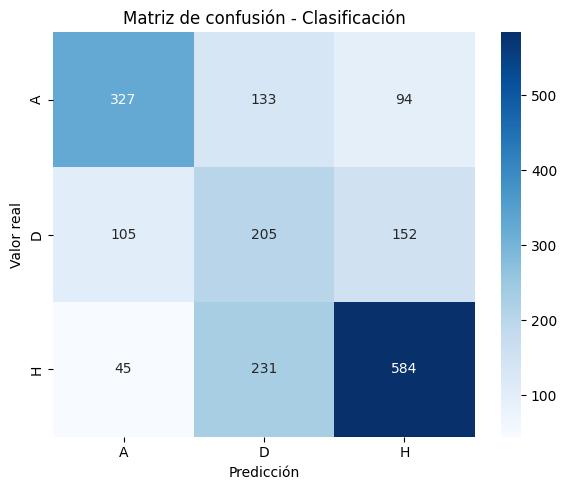

In [17]:
matriz_confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder_resultado.classes_,
    yticklabels=label_encoder_resultado.classes_
)
plt.title('Matriz de confusión - Clasificación')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

**Interpretación:** el modelo se compara contra el baseline de la clase mayoritaria. Si el accuracy supera ese valor, el modelo aporta información adicional frente a simplemente predecir siempre el resultado más frecuente. En fútbol, el rendimiento debe interpretarse considerando que existen factores externos no presentes en el dataset.

### 5.2 Evaluación del modelo de regresión

In [18]:
y_pred_reg = modelo_regresion.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R2: {r2:.3f}')

reg_results = pd.DataFrame({
    'GolesReales': y_test_reg,
    'GolesPredichos': y_pred_reg
}).reset_index(drop=True)
display(reg_results.head(10))

MAE: 1.006
RMSE: 1.227
R2: 0.463


,GolesReales,GolesPredichos
0,2,1.450168
1,3,1.450168
2,4,3.416686
3,2,2.501942
4,0,1.450168
5,1,2.573501
6,6,2.501942
7,1,2.501942
8,4,3.416686
9,4,2.501942


**Interpretación:** MAE y RMSE indican el error del modelo al estimar goles totales. R² resume qué parte de la variabilidad de los goles logra explicar el modelo con información disponible al descanso.

### 5.3 Evaluación del modelo K-Means

In [19]:
labels_final = team_df['Cluster']
silhouette_final = silhouette_score(team_scaled, labels_final)
calinski_final = calinski_harabasz_score(team_scaled, labels_final)
davies_final = davies_bouldin_score(team_scaled, labels_final)

print(f'Silhouette: {silhouette_final:.3f}')
print(f'Calinski-Harabasz: {calinski_final:.3f}')
print(f'Davies-Bouldin: {davies_final:.3f}')

display(team_df.groupby('ClusterLabel')[cluster_features + ['Matches']].mean().round(3))

Silhouette: 0.332
Calinski-Harabasz: 27.605
Davies-Bouldin: 1.165


,GoalsForAvg,GoalsAgainstAvg,ShotsAvg,ShotsOnTargetAvg,CornersAvg,YellowCardsAvg,RedCardsAvg,PointsPerMatch,Matches
ClusterLabel,,,,,,,,,
Alto rendimiento,1.821,1.046,14.604,6.614,6.272,1.551,0.069,1.878,931.333
Rendimiento bajo,0.945,1.808,10.260,3.781,4.534,1.723,0.048,0.845,134.333
Rendimiento medio,1.170,1.522,11.177,4.888,5.067,1.646,0.080,1.143,385.903


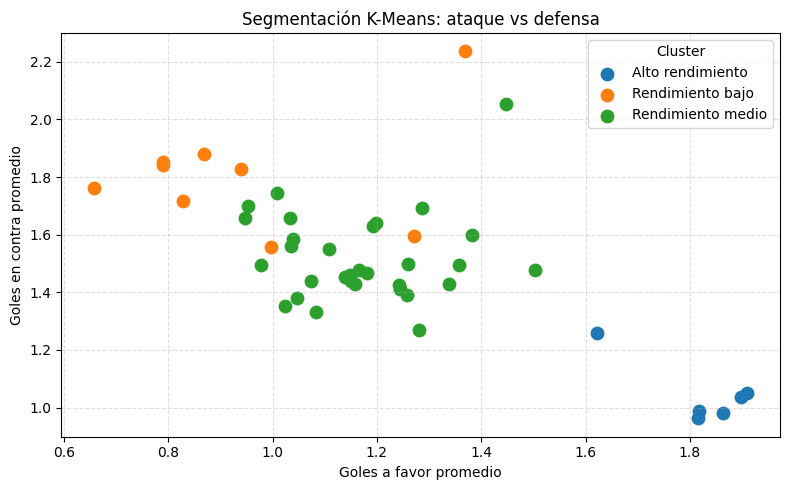

In [20]:
plt.figure(figsize=(8, 5))
for label, subset in team_df.groupby('ClusterLabel'):
    plt.scatter(subset['GoalsForAvg'], subset['GoalsAgainstAvg'], s=80, label=label)
plt.title('Segmentación K-Means: ataque vs defensa')
plt.xlabel('Goles a favor promedio')
plt.ylabel('Goles en contra promedio')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación:** la segmentación permite distinguir equipos de alto rendimiento, medio rendimiento y bajo rendimiento. Esta información es útil para comparar perfiles deportivos y construir visualizaciones ejecutivas en Power BI.

### 5.4 Hallazgos para la toma de decisiones

1. **El marcador al medio tiempo es una señal relevante** para anticipar el resultado final.
2. **La localía mantiene peso histórico**, por lo que debe considerarse en la lectura de resultados.
3. **Las remontadas son menos frecuentes que la conservación de ventaja**, lo que ayuda a interpretar escenarios de riesgo durante el partido.
4. **La regresión de goles complementa la clasificación**, porque entrega una aproximación del volumen ofensivo esperado.
5. **K-Means permite comparar equipos por perfil**, no solo por resultados aislados.

---
## Fase 6 — Despliegue, Power BI y bonus API

El proyecto contempla un panel de Power BI con visualización de resultados del notebook para apoyar la toma de decisiones. Para mantener el dashboard simple, se exportan solo 4 CSV finales.


### 6.1 Exportación de CSV finales para Power BI

In [21]:
# 1) Resumen por temporada:
resumen_resultados = (
    df.groupby(['Season', 'FullTimeResult'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)
for col in ['H', 'D', 'A']:
    if col not in resumen_resultados.columns:
        resumen_resultados[col] = 0

resumen_goles = (
    df.groupby('Season')
      .agg(
          Partidos=('Season', 'count'),
          GolesLocal=('FullTimeHomeGoals', 'sum'),
          GolesVisitante=('FullTimeAwayGoals', 'sum'),
          GolesTotales=('TotalFullTimeGoals', 'sum')
      )
      .reset_index()
)
resumen_goles['GolesPorPartido'] = resumen_goles['GolesTotales'] / resumen_goles['Partidos']

# Remontadas por temporada
remontadas_df = df[
    ((df['HalfTimeResult'] == 'A') & (df['FullTimeResult'] == 'H')) |
    ((df['HalfTimeResult'] == 'H') & (df['FullTimeResult'] == 'A'))
].copy()
remontadas_df['TipoRemontada'] = np.where(
    remontadas_df['FullTimeResult'] == 'H',
    'Remontada local',
    'Remontada visitante'
)
remontadas_por_temporada = remontadas_df.groupby('Season').size().rename('Remontadas').reset_index()

pb_resumen_temporada = resumen_goles.merge(resumen_resultados, on='Season', how='left')
pb_resumen_temporada = pb_resumen_temporada.merge(remontadas_por_temporada, on='Season', how='left')
pb_resumen_temporada['Remontadas'] = pb_resumen_temporada['Remontadas'].fillna(0).astype(int)
pb_resumen_temporada = pb_resumen_temporada.rename(columns={
    'H': 'VictoriasLocal',
    'D': 'Empates',
    'A': 'VictoriasVisitante'
})

# 2) Métricas principales de modelos
pb_metricas_modelos = pd.DataFrame([
    {'Modelo': 'Clasificacion', 'Metrica': 'Accuracy', 'Valor': accuracy},
    {'Modelo': 'Clasificacion', 'Metrica': 'Balanced Accuracy', 'Valor': balanced_acc},
    {'Modelo': 'Clasificacion', 'Metrica': 'Baseline Clase Mayoritaria', 'Valor': baseline},
    {'Modelo': 'Clasificacion', 'Metrica': 'Cross Validation Accuracy', 'Valor': cv_scores.mean()},
    {'Modelo': 'Regresion', 'Metrica': 'MAE', 'Valor': mae},
    {'Modelo': 'Regresion', 'Metrica': 'RMSE', 'Valor': rmse},
    {'Modelo': 'Regresion', 'Metrica': 'R2', 'Valor': r2},
    {'Modelo': 'K-Means', 'Metrica': 'Silhouette', 'Valor': silhouette_final},
    {'Modelo': 'K-Means', 'Metrica': 'Calinski-Harabasz', 'Valor': calinski_final},
    {'Modelo': 'K-Means', 'Metrica': 'Davies-Bouldin', 'Valor': davies_final},
])

# 3) Clusters de equipos
pb_clusters_equipos = team_df.copy()

# 4) Remontadas para análisis de decisiones
pb_remontadas = remontadas_df[[
    'Season', 'MatchDate', 'HomeTeam', 'AwayTeam',
    'HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HalfTimeResult',
    'FullTimeHomeGoals', 'FullTimeAwayGoals', 'FullTimeResult',
    'TipoRemontada'
]].copy()

# Exportación
pb_resumen_temporada.to_csv(POWERBI_DIR / 'pb_resumen_temporada.csv', index=False)
pb_metricas_modelos.to_csv(POWERBI_DIR / 'pb_metricas_modelos.csv', index=False)
pb_clusters_equipos.to_csv(POWERBI_DIR / 'pb_clusters_equipos.csv', index=False)
pb_remontadas.to_csv(POWERBI_DIR / 'pb_remontadas.csv', index=False)

print('CSV finales para Power BI exportados en:', POWERBI_DIR)
print('\nArchivos:')
for file in sorted(POWERBI_DIR.glob('*.csv')):
    print('-', file)

CSV finales para Power BI exportados en: salidas_proyecto/powerbi

Archivos:
- salidas_proyecto/powerbi/pb_clusters_equipos.csv
- salidas_proyecto/powerbi/pb_metricas_modelos.csv
- salidas_proyecto/powerbi/pb_remontadas.csv
- salidas_proyecto/powerbi/pb_resumen_temporada.csv


**Justificación de los 4 CSV:**

| Archivo | Uso en Power BI |
|---|---|
| `pb_resumen_temporada.csv` | Goles, resultados y remontadas por temporada |
| `pb_metricas_modelos.csv` | Tarjetas KPI de clasificación, regresión y K-Means |
| `pb_clusters_equipos.csv` | Gráficos de segmentación y perfiles de equipos |
| `pb_remontadas.csv` | Análisis específico de cambios de resultado |

No se exportan tablas técnicas completas para el dashboard porque esas se revisan en el notebook. Power BI se usa como panel ejecutivo de visualización y toma de decisiones.

### 6.2 Exportación de modelos `.pkl`

In [22]:
joblib.dump(modelo_clasificacion, MODELOS_DIR / 'modelo_clasificacion_resultado.pkl')
joblib.dump(modelo_regresion, MODELOS_DIR / 'modelo_regresion_goles.pkl')
joblib.dump(modelo_kmeans, MODELOS_DIR / 'modelo_kmeans_equipos.pkl')
joblib.dump(scaler_kmeans, MODELOS_DIR / 'scaler_kmeans.pkl')
joblib.dump(label_encoder_resultado, MODELOS_DIR / 'label_encoder_resultado.pkl')

print('Modelos exportados en:', MODELOS_DIR)
for file in sorted(MODELOS_DIR.glob('*.pkl')):
    print('-', file)

Modelos exportados en: salidas_proyecto/modelos
- salidas_proyecto/modelos/label_encoder_resultado.pkl
- salidas_proyecto/modelos/modelo_clasificacion_resultado.pkl
- salidas_proyecto/modelos/modelo_kmeans_equipos.pkl
- salidas_proyecto/modelos/modelo_regresion_goles.pkl
- salidas_proyecto/modelos/scaler_kmeans.pkl


### 6.3 API Flask simple como bonus

In [23]:
app_flask = "\nfrom flask import Flask, request, jsonify\nimport joblib\nimport pandas as pd\n\napp = Flask(__name__)\n\nmodelo = joblib.load('modelos/modelo_clasificacion_resultado.pkl')\nlabel_encoder = joblib.load('modelos/label_encoder_resultado.pkl')\n\nFEATURES = [\n    'HalfTimeHomeGoals',\n    'HalfTimeAwayGoals',\n    'HalfTimeResult_Encoded',\n    'HalfTimeGoalDiff',\n    'TotalHalfTimeGoals'\n]\n\n@app.route('/predecir', methods=['POST'])\ndef predecir():\n    data = request.get_json()\n\n    home_goals = int(data.get('HalfTimeHomeGoals', 0))\n    away_goals = int(data.get('HalfTimeAwayGoals', 0))\n    half_time_result_encoded = int(data.get('HalfTimeResult_Encoded', 1))\n\n    fila = pd.DataFrame([{\n        'HalfTimeHomeGoals': home_goals,\n        'HalfTimeAwayGoals': away_goals,\n        'HalfTimeResult_Encoded': half_time_result_encoded,\n        'HalfTimeGoalDiff': home_goals - away_goals,\n        'TotalHalfTimeGoals': home_goals + away_goals\n    }])[FEATURES]\n\n    pred = modelo.predict(fila)[0]\n    resultado = label_encoder.inverse_transform([pred])[0]\n\n    return jsonify({\n        'prediccion_codigo': int(pred),\n        'prediccion_resultado': resultado,\n        'interpretacion': {\n            'H': 'Victoria local',\n            'D': 'Empate',\n            'A': 'Victoria visitante'\n        }.get(resultado, resultado)\n    })\n\nif __name__ == '__main__':\n    app.run(debug=True)\n"

api_path = OUTPUT_DIR / 'app_flask_premier.py'
api_path.write_text(app_flask, encoding='utf-8')

requirements = '\nflask\npandas\nscikit-learn\njoblib\n'
(OUTPUT_DIR / 'requirements.txt').write_text(requirements.strip() + '\n', encoding='utf-8')

print('API Flask exportada en:', api_path)
print('Requirements exportado en:', OUTPUT_DIR / 'requirements.txt')

API Flask exportada en: salidas_proyecto/app_flask_premier.py
Requirements exportado en: salidas_proyecto/requirements.txt


In [25]:
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. Definir variables predictoras (usando las que ya creaste en tu Notebook)
# Debes asegurarte de que HalfTimeGoalDiff y TotalHalfTimeGoals estén en tu df
columnas_regresion = ['HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HalfTimeGoalDiff', 'TotalHalfTimeGoals']

X_reg = df[columnas_regresion]
y_reg = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals'] # El total de goles finales

# 2. Entrenar el modelo
modelo_regresion = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_regresion.fit(X_reg, y_reg)

# 3. Exportar el modelo a la carpeta que definiste en tu Notebook (MODELOS_DIR)
ruta_regresion = MODELOS_DIR / 'modelo_regresion.pkl'
joblib.dump(modelo_regresion, ruta_regresion)

print(f"Modelo de regresión guardado en: {ruta_regresion}")

Modelo de regresión guardado en: salidas_proyecto/modelos/modelo_regresion.pkl
